In [13]:
#######################################################################################################
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import os
import sys

# Get the current notebook's directory
notebook_dir = os.path.abspath('')
# Add the relative path to your Codes directory
codes_path = os.path.join(notebook_dir, "..", "Codes")
codes_path = os.path.abspath(codes_path)  # Normalize the path
# Add to path if not already there
if codes_path not in sys.path:
    sys.path.insert(1, codes_path)
from myUtils import *

In [14]:
def detect_turning_points(years, values, slope_threshold=0.5):
    """
    Detect turning points in a time series where the slope changes significantly.
    
    Parameters:
    - years: array of years (x-values)
    - values: array of measurements (y-values)
    - slope_threshold: minimum absolute difference in slopes to consider a turning point
    
    Returns:
    - turning_points: indices of detected turning points
    - turning_years: years where turning points occur
    - turning_values: values at turning points
    """
    # Calculate time intervals
    time_intervals = np.diff(years)
    
    # Calculate slopes between consecutive points
    slopes = np.diff(values) / time_intervals
    
    turning_points = []
    # Start from the second point and end at the second-to-last point
    for i in range(1, len(slopes)):
        # Calculate slope difference
        slope_diff = slopes[i] - slopes[i-1]
        
        # Check for sign change
        sign_change = (slopes[i-1] > 0 and slopes[i] < 0) or (slopes[i-1] < 0 and slopes[i] > 0)
        
        # Handle the case where one slope is exactly zero
        if slopes[i-1] == 0 or slopes[i] == 0:
            sign_change = True
        
        # Check if slope exceeds threshold and changes sign
        if sign_change and (abs(slope_diff) > slope_threshold):
            # The turning point is at index i in the original series
            turning_points.append(i)
    
    turning_years = years[turning_points]
    turning_values = values[turning_points]
    
    return turning_points, turning_years, turning_values

In [15]:
# Custom regions shapefiles 
shapef = os.path.join(MAINPATH, 'Data/SHAPEFILES/world-custom_regions_r.shp')
gdf1 = gpd.read_file(shapef)
gdf1 = gdf1.to_crs("ESRI:54009")
REGIONS = gdf1['custom_reg']

# Define the fixed number of rows (continents)
continent_order = ["Africa", "Asia", "America", "Oceania", "Europe"]
rows = len(continent_order)

In [23]:
REGIONS = gdf1['custom_reg'].unique()
DF_all = pd.DataFrame()
SUBP1 = ['FHN']

for subp1 in SUBP1:
    print(subp1)
    
    # Load data once per subp1
    PATHL = os.path.join(MAINPATH, 'Data', 'OUTPUT', subp1, subp1+'_{window}_{year}.tif')
    df = return_df(PATHL, gdf1)
    
    # Create a DataFrame with all regions
    DF = pd.DataFrame()
    for region in REGIONS:
        region_df = df[df["region"] == region].sort_values("year")
        DF = pd.concat([DF, region_df], ignore_index=True)
    
    # Calculate relative temporal variation
    col_to_plot = 'median'
    new_col = col_to_plot+'_rel'
    DF[new_col] = 0
    
    for region in REGIONS:
        # Get indices and sorted data for this region
        region_indices = DF[DF["region"] == region].index
        df_region = DF[DF["region"] == region].sort_values("year").reset_index(drop=True)
        
        if len(df_region) > 0:  # Add safety check
            # Calculate relative change
            signal = df_region[col_to_plot].values
            baseline = signal[0]
            if baseline != 0:  # Add safety check for division by zero
                signal = 100 * (signal - baseline) / baseline
                # Update values in original DataFrame
                DF.loc[region_indices, new_col] = signal
    
    # First iteration: initialize DF_all with structure
    if DF_all.empty and not DF.empty:
        DF_all = pd.DataFrame({
            'year': DF['year'],
            'region': DF['region']
        })
    
    # Add columns for this subp1
    if not DF.empty:
        new_col1 = col_to_plot + f'_{subp1}'
        new_col2 = new_col + f'_{subp1}'
        DF_all[new_col1] = DF[col_to_plot]
        DF_all[new_col2] = DF[new_col]

FHN


In [24]:
DF_all["Continent"] = DF_all["region"].map(REGION_TO_CONTINENT)
# Get unique regions per continent
regions_by_continent = {continent: DF_all[DF_all["Continent"] == continent]["region"].unique() \
                        for continent in continent_order}
# Determine the maximum number of columns based on the continent with the most regions
cols = max(len(regions) for regions in regions_by_continent.values())
DF_all.head()

,year,region,median_FHN,median_rel_FHN,Continent
0,1975,Central Asia,0.091887,0.000000,Asia
1,1980,Central Asia,0.090370,-1.651589,Asia
2,1985,Central Asia,0.089769,-2.305636,Asia
3,1990,Central Asia,0.089529,-2.566572,Asia
4,1995,Central Asia,0.092708,0.892823,Asia


Eastern Africa: found 4 turning points
Middle Africa: found 0 turning points
Northern Africa: found 2 turning points
Southern Africa: found 4 turning points
Western Africa: found 1 turning points
Central Asia: found 2 turning points
Eastern Asia: found 2 turning points
South-Eastern Asia: found 2 turning points
Southern Asia: found 5 turning points
Western Asia: found 6 turning points
Northern America: found 4 turning points
South America: found 0 turning points
Oceania: found 2 turning points
Eastern Europe: found 2 turning points
Northern Europe: found 4 turning points
Southern Europe: found 2 turning points
Western Europe: found 0 turning points


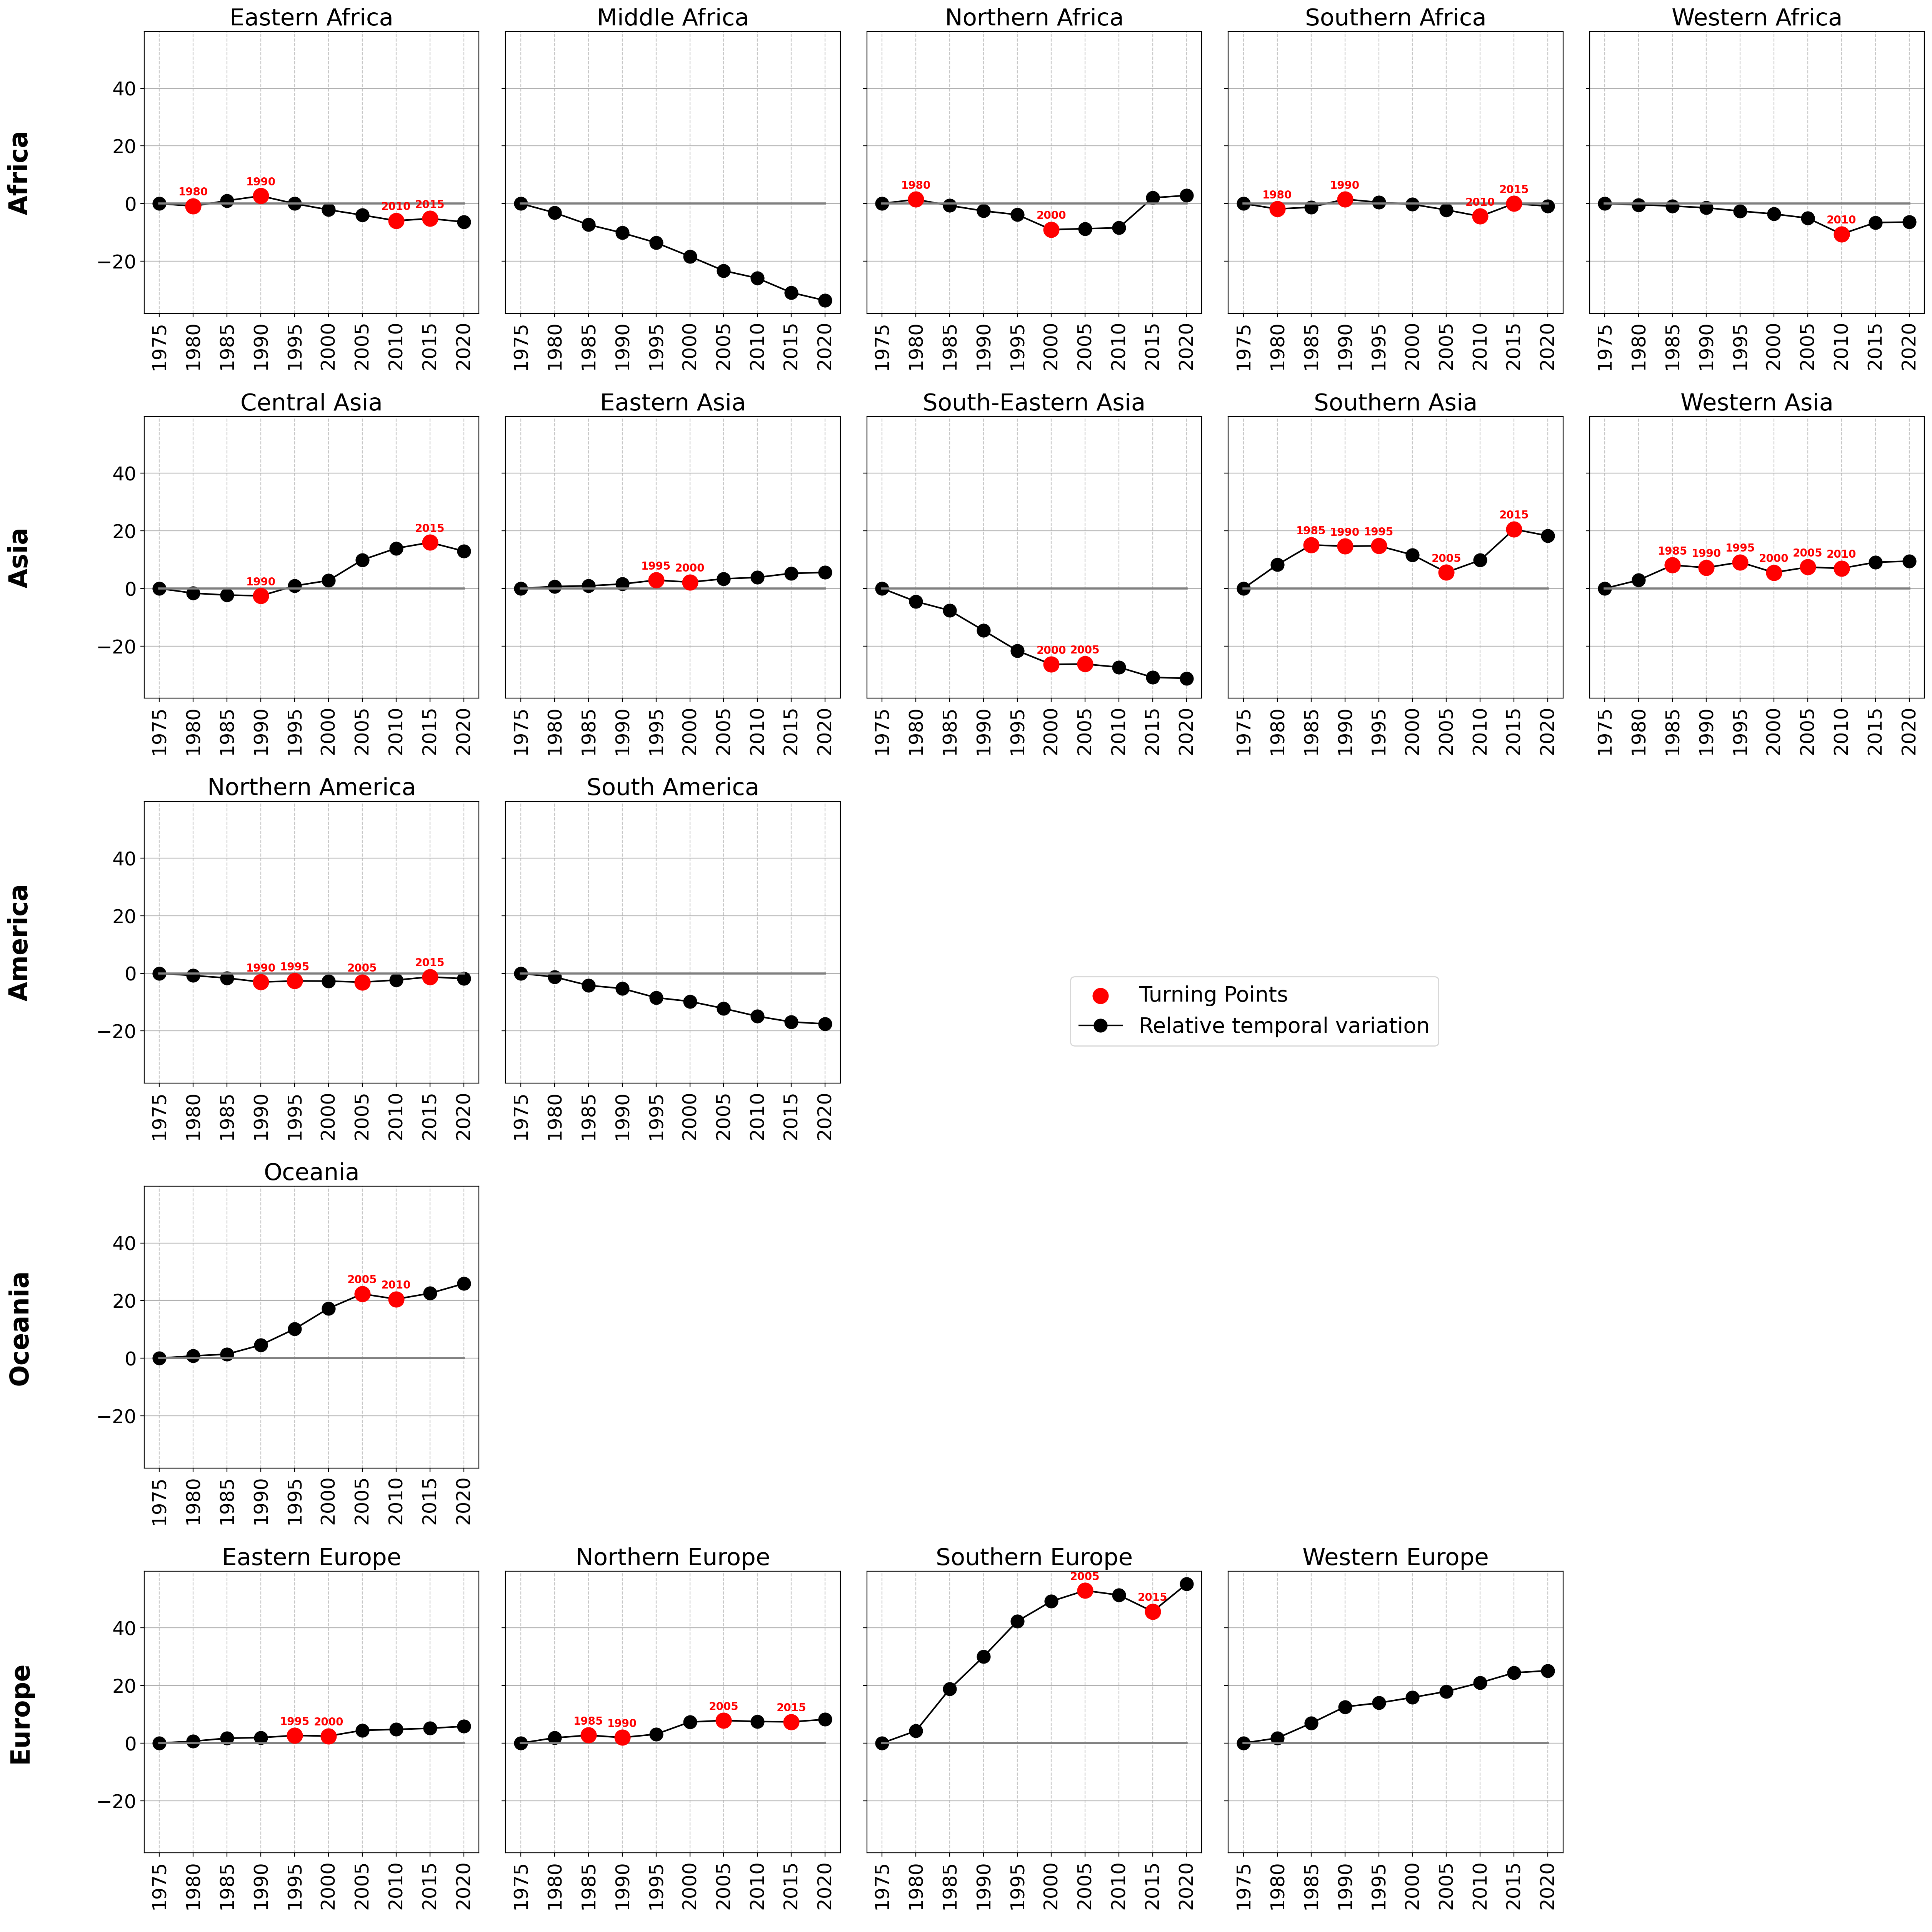

In [25]:
col_to_plot = 'median_rel_FHN'
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), 
                         constrained_layout=True, sharex=False, sharey=True)
# Ensure axes is a 2D array
if rows == 1:
    axes = np.expand_dims(axes, axis=0)
if cols == 1:
    axes = np.expand_dims(axes, axis=1)
    
# Dictionary to store unique legend handles and labels
unique_handles = {}    

# Iterate over continents and regions to populate the subplots
for row_idx, continent in enumerate(continent_order):
    regions = regions_by_continent[continent]
    for col_idx, region in enumerate(regions):
        ax = axes[row_idx, col_idx]  # Get the corresponding subplot
        ax = set_font(ax, 18)
        
        # Get data for this region
        df_region = DF_all[DF_all["region"] == region].sort_values("year")
        
        # Calculate turning points
        slope_threshold = 0.001  # Adjust as needed
        years = df_region['year'].values
        values = df_region[col_to_plot].values
        
        indices, turning_years, turning_values = detect_turning_points(years, values, slope_threshold)
        print(f"{region}: found {len(turning_years)} turning points")
        
        # Plot the main line
        line1, = ax.plot(df_region["year"], df_region[col_to_plot], marker="o", 
                         markersize=12, color="black", label="Relative temporal variation")
        
        # Plot the zero reference line
        line2, = ax.plot([1975, 2020], [0, 0], lw=2, color='gray')
        
        # Plot turning points with higher z-order to ensure visibility
        if len(turning_years) > 0:
            tp_scatter = ax.scatter(turning_years, turning_values, color='red', 
                                   s=200, zorder=10, label='Turning Points')
            unique_handles['Turning Points'] = tp_scatter
            
            # Optional: Add text labels for turning points
            for year, value in zip(turning_years, turning_values):
                ax.annotate(f"{year}", (year, value), xytext=(0, 10), 
                           textcoords='offset points', ha='center', color='red', fontweight='bold')
        
        # Store handles for legend
        unique_handles['Relative temporal variation'] = line1
        
        # Set labels and title
        ax.set_xlabel(" ")
        ax.set_ylabel(" ")
        ax.set_title(region, size=22)
        ax.grid(True)
        
    # Hide unused subplots in this row
    for col_idx in range(len(regions), cols):
        fig.delaxes(axes[row_idx, col_idx])

# Set row labels (continent names)
for row_idx, continent in enumerate(continent_order):
    ax = axes[row_idx, 0]
    ax.set_ylabel(f"{continent}\n\n ", fontsize=24, fontweight="bold")

# Place the legend outside the plot
fig.legend(unique_handles.values(), unique_handles.keys(),
           bbox_to_anchor=(0.65, 0.5),  # Adjust position as needed
           loc='upper center', ncol=len(unique_handles)-1, fontsize=20)

# Set x-axis ticks
all_years = np.arange(1975, 2021, 5)
for ax in axes.flatten():
    if ax.get_subplotspec().get_geometry()[2] < rows * cols:  # Check if not deleted
        ax.set_xticks(all_years)
        ax.set_xticklabels(all_years, rotation=90)
        ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.7)

plt.show()

In [26]:
fout = '../Figures/FHN_temporal_rel.pdf'
fig.savefig(fout, dpi=300, bbox_inches='tight')

In [27]:
import pymannkendall as mk  # Use pymannkendall for Sen's slope and Mann-Kendall test
import seaborn as sns
from scipy import stats

results_list = []
# For each region, plot data and calculate Sen's slope
for i, region in enumerate(REGIONS):
    df_region = DF_all[DF_all["region"] == region].sort_values("year")
    
    # Extract x and y data
    x = df_region['year'].values
    y = df_region[col_to_plot].values
    
    # Plot the original data
    
    # Run Mann-Kendall test and Sen's slope analysis
    mk_result = mk.original_test(y, alpha=0.05)
    
    # Get the slope
    slope = mk_result.slope

    # Calculate the trend line using Sen's slope
    y_start = mk_result.intercept + mk_result.slope * x[0]
    y_end = mk_result.intercept + mk_result.slope * x[-1]

    # Get significance stars
    significance = ''
    if mk_result.p < 0.001:
        significance = '***'
    elif mk_result.p < 0.01:
        significance = '**'
    elif mk_result.p < 0.05:
        significance = '*'
    else:
        significance = 'ns'
    
    # Add results to list
    results_list.append({
        'Region': region,
        'Slope': slope,
        'p-value': mk_result.p,
        'Significance': significance,
        'Trend': mk_result.trend,
        'Intercept': mk_result.intercept
    })

# Create a results dataframe
results_df = pd.DataFrame(results_list)

In [28]:
results_df.reset_index(drop=True)

,Region,Slope,p-value,Significance,Trend,Intercept
0,Central Asia,2.179106,0.012266,*,increasing,-7.978455
1,Eastern Africa,-0.894641,0.007290,**,decreasing,2.494588
2,Eastern Asia,0.610232,0.000172,***,increasing,-0.221143
3,Eastern Europe,0.644007,0.000172,***,increasing,-0.359149
4,Middle Africa,-3.810855,0.000083,***,decreasing,1.193205
5,Northern Africa,-0.853732,0.858028,ns,no trend,2.216460
6,Northern America,-0.139619,0.371093,ns,no trend,-1.460998
7,Northern Europe,0.922490,0.001282,**,increasing,1.056924
8,Oceania,3.200067,0.000172,***,increasing,-0.679971
9,South America,-2.107668,0.000083,***,decreasing,0.392778


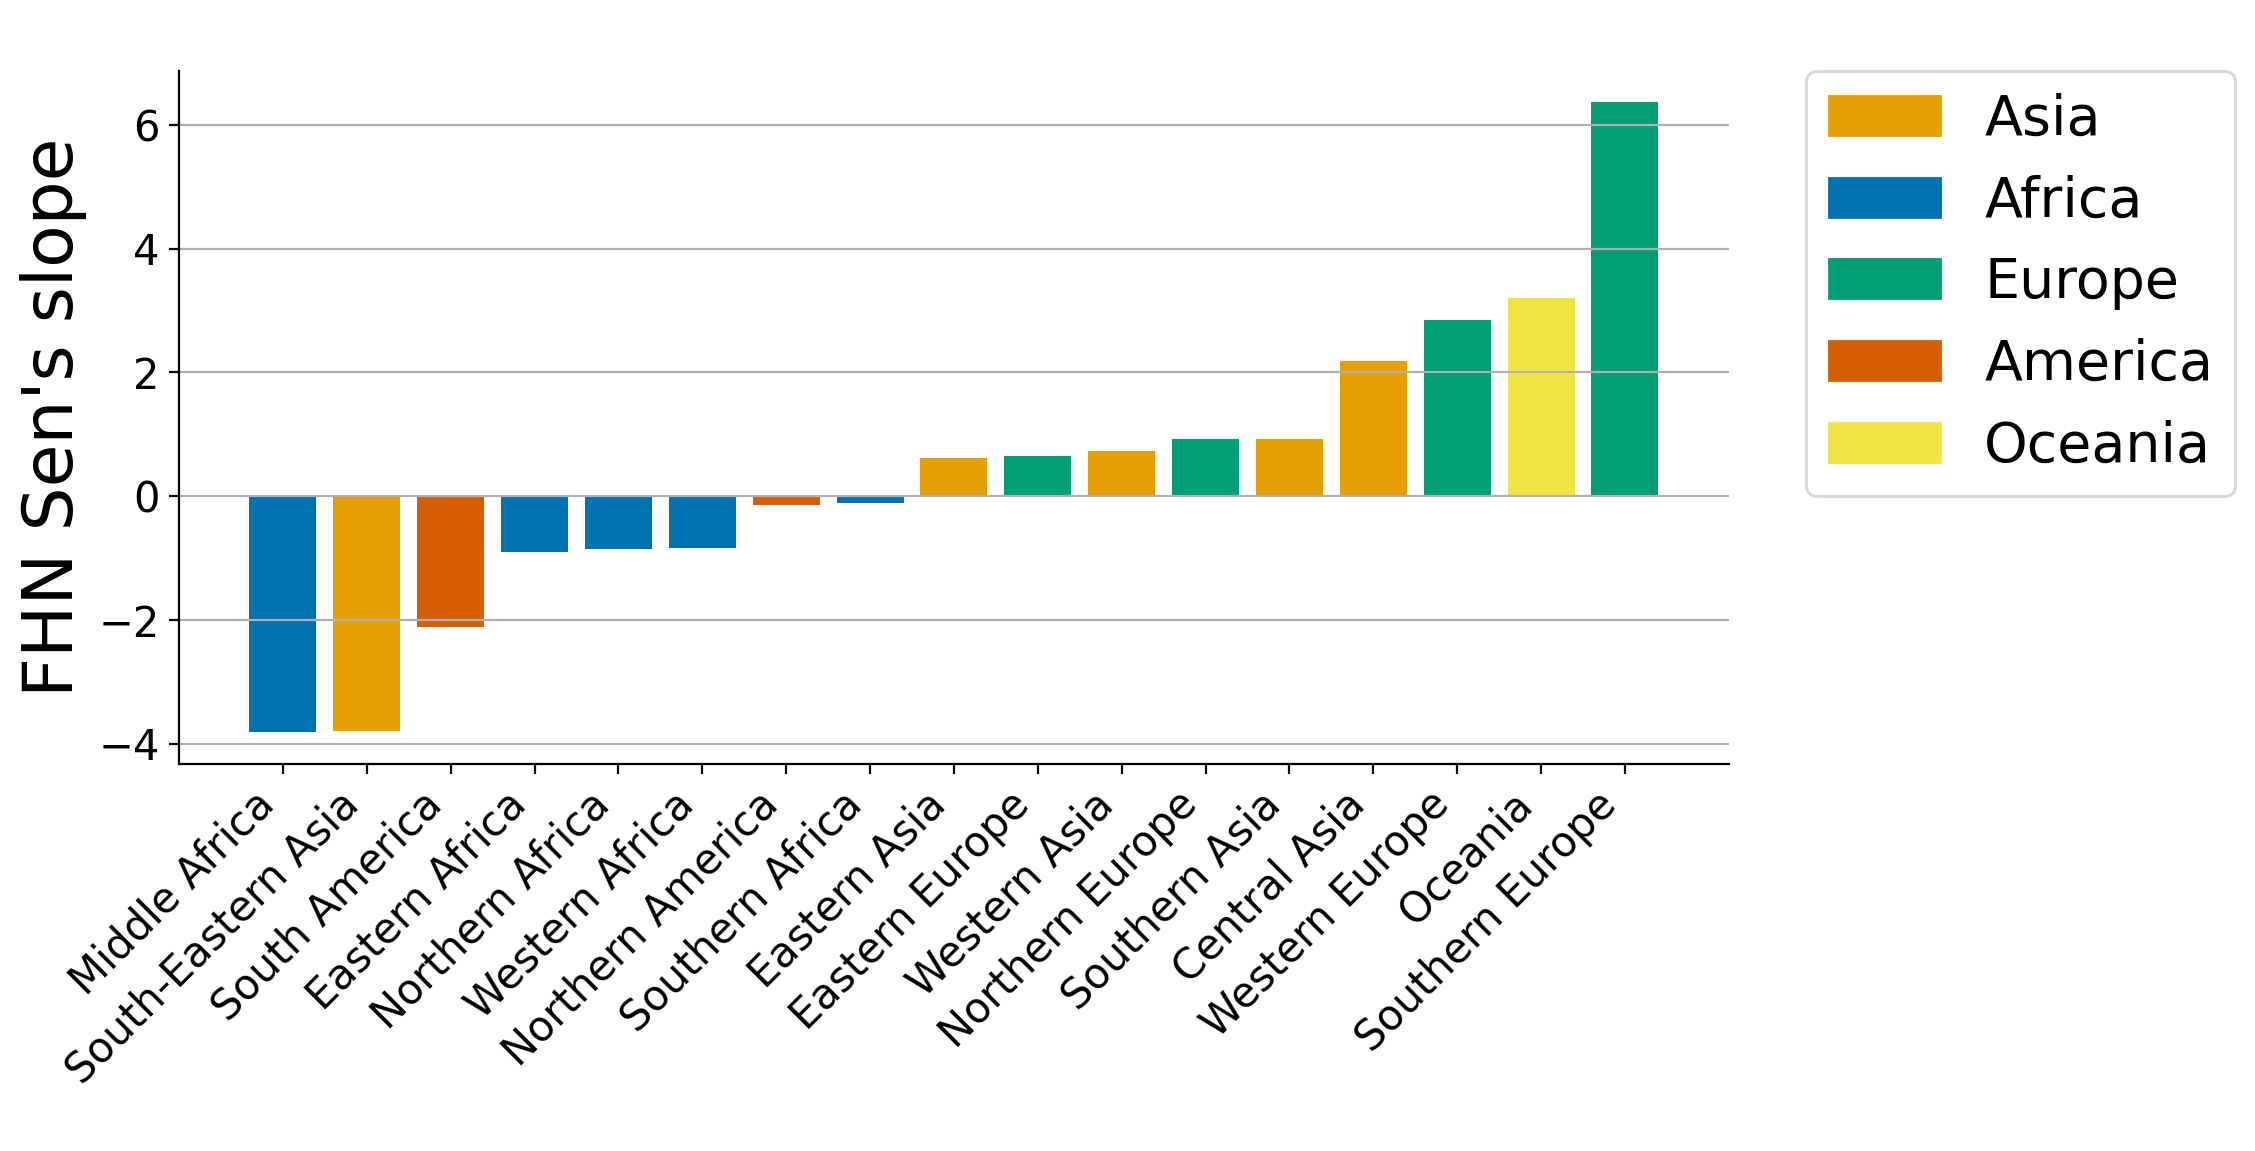

In [33]:
results_df = results_df.sort_values('Slope')
colors = results_df['Region'].map(REGION_TO_CONTINENT).map(CONTINENT_COLORS)
# Plotting the bar plot
f, ax = plt.subplots(figsize=(10, 4.5))
ax = set_font(ax, 15)
plt.bar(results_df['Region'], results_df['Slope'], color=colors)
# Adding labels and title
plt.xlabel(' ')
plt.ylabel('FHN '+"Sen's slope", size=25)
plt.title(' ', size=16)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Creating legend patches
patches = [mpatches.Patch(color=color, label=continent) for continent, color in CONTINENT_COLORS.items()]
# Adding the legend outside the plot
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=20)
plt.xticks(rotation=45, ha='right');

In [34]:
fout = '../Figures/FHN_sen_slope.pdf'
f.savefig(fout, dpi=300, bbox_inches='tight')

In [39]:
df_region

,year,region,median_FHN,median_rel_FHN,Continent
160,1975,Western Europe,0.255875,0.000000,Europe
161,1980,Western Europe,0.260336,1.743600,Europe
162,1985,Western Europe,0.273490,6.884148,Europe
163,1990,Western Europe,0.288094,12.591623,Europe
164,1995,Western Europe,0.291526,13.933080,Europe
165,2000,Western Europe,0.296415,15.843644,Europe
166,2005,Western Europe,0.301732,17.921799,Europe
167,2010,Western Europe,0.309515,20.963448,Europe
168,2015,Western Europe,0.318331,24.408741,Europe
169,2020,Western Europe,0.320205,25.141327,Europe


In [40]:
results_list = []
# For each region, plot data and calculate Sen's slope
for i, region in enumerate(REGIONS):
    df_region = DF_all[DF_all["region"] == region].sort_values("year")
    
    # Extract x and y data
    x = df_region['year'].values
    y = df_region['median_FHN'].values
    


    # Calculate the trend line using Sen's slope
    y_start = y[0]
    y_end   =  y[-1]
    slope = 100*(y_end - y_start) / y_start

    # Get significance stars
    significance = ''
    if mk_result.p < 0.001:
        significance = '***'
    elif mk_result.p < 0.01:
        significance = '**'
    elif mk_result.p < 0.05:
        significance = '*'
    else:
        significance = 'ns'
    
    # Add results to list
    results_list.append({
        'Region': region,
        'Rel_change': slope
    })

# Create a results dataframe
results_df1 = pd.DataFrame(results_list)


In [41]:
results_df1

,Region,Rel_change
0,Central Asia,12.948104
1,Eastern Africa,-6.387893
2,Eastern Asia,5.556444
3,Eastern Europe,5.813708
4,Middle Africa,-33.660560
5,Northern Africa,2.821623
6,Northern America,-1.844602
7,Northern Europe,8.210410
8,Oceania,25.875269
9,South America,-17.549936


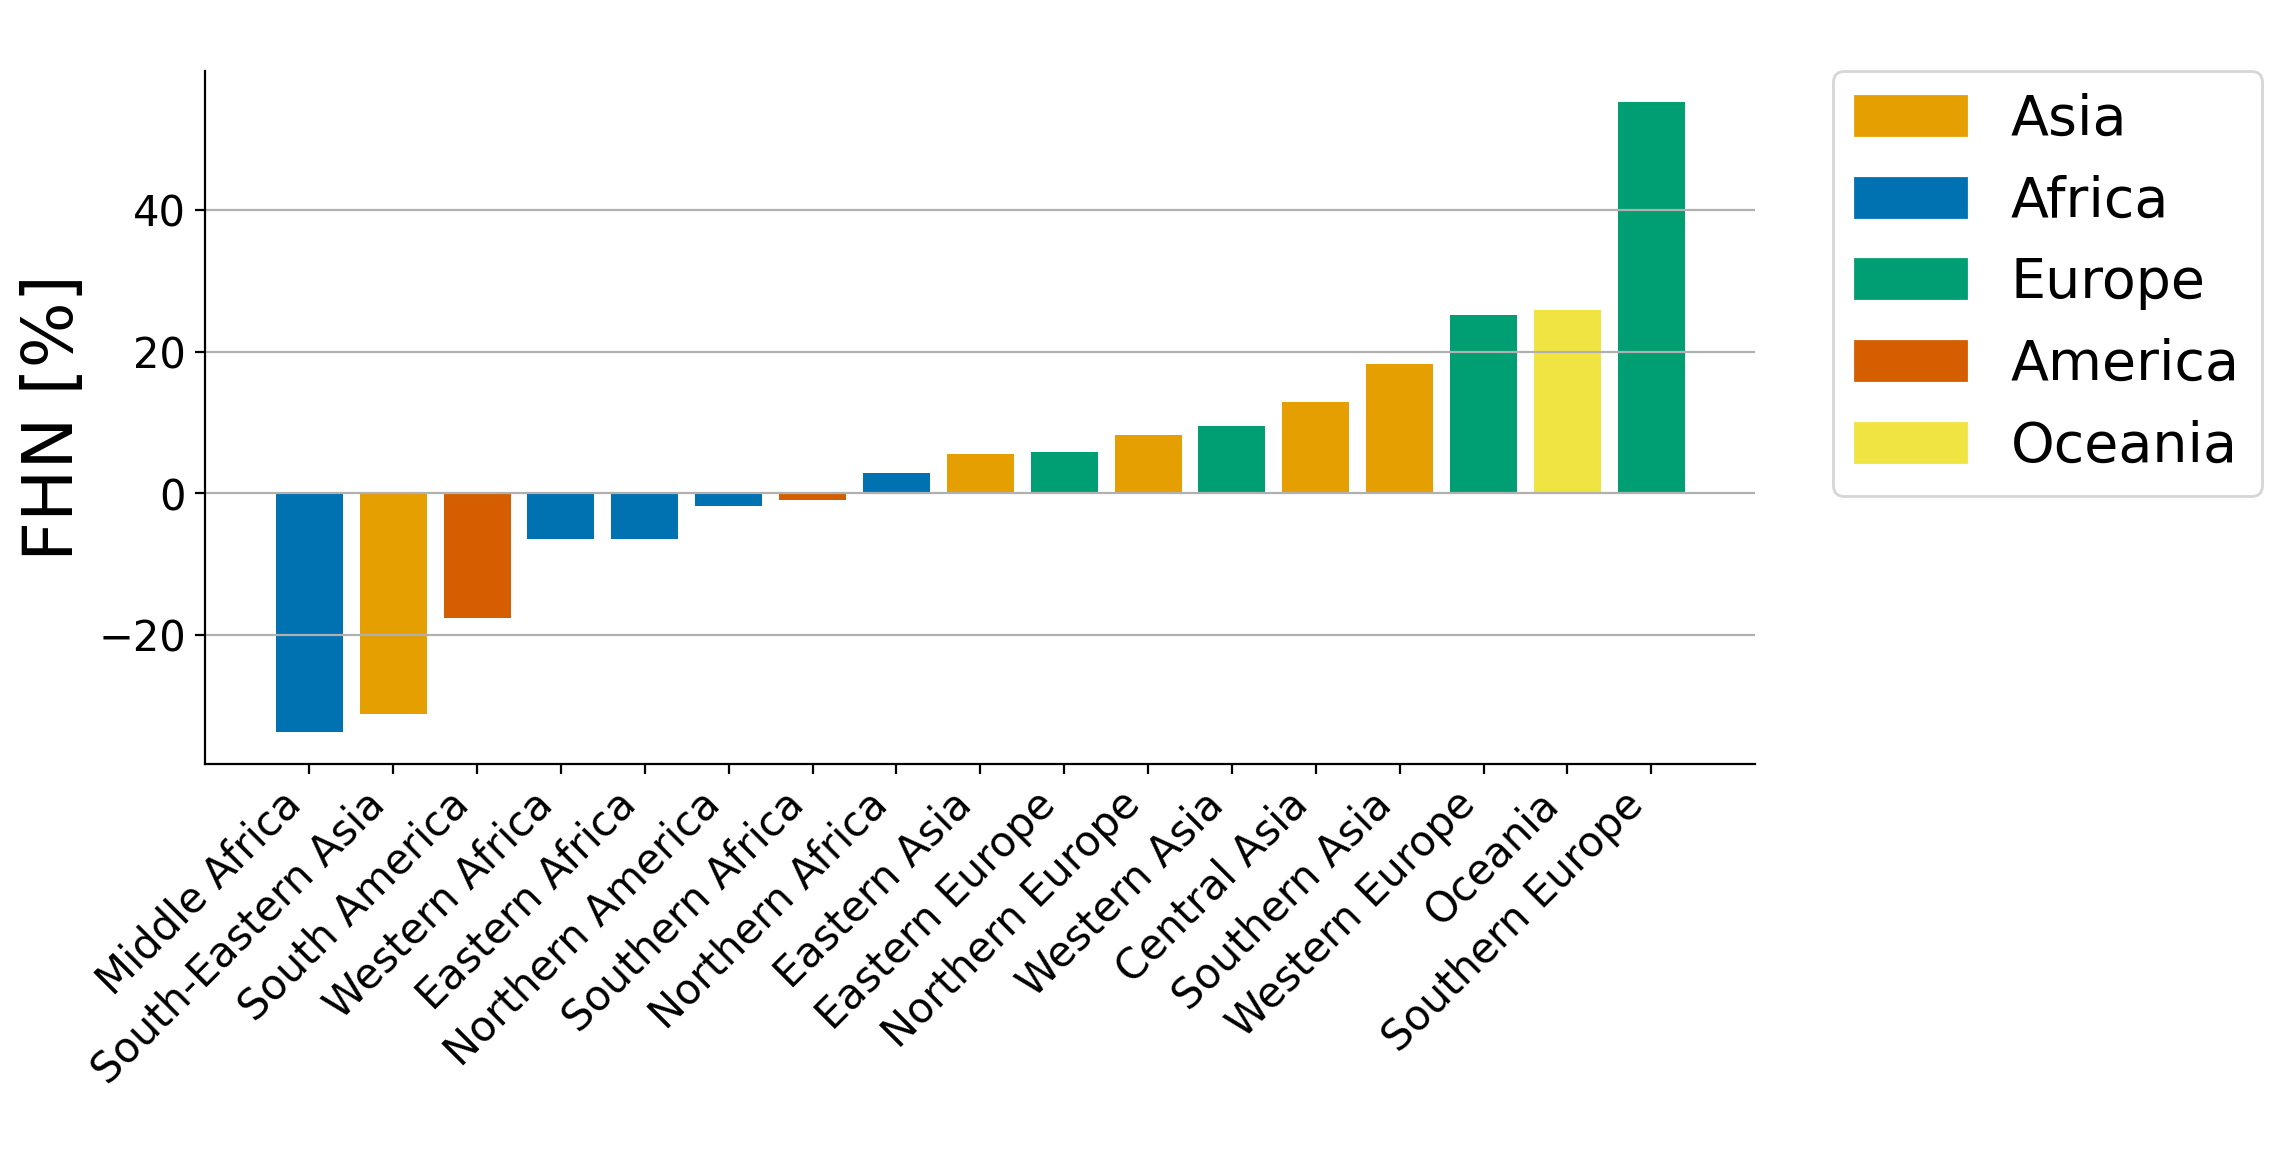

In [42]:
results_df1 = results_df1.sort_values('Rel_change')
colors = results_df['Region'].map(REGION_TO_CONTINENT).map(CONTINENT_COLORS)
# Plotting the bar plot
f, ax = plt.subplots(figsize=(10, 4.5))
ax = set_font(ax, 15)
plt.bar(results_df1['Region'], results_df1['Rel_change'], color=colors)
# Adding labels and title
plt.xlabel(' ')
plt.ylabel('FHN [%]', size=25)
plt.title(' ', size=16)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Creating legend patches
patches = [mpatches.Patch(color=color, label=continent) for continent, color in CONTINENT_COLORS.items()]
# Adding the legend outside the plot
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=20)
plt.xticks(rotation=45, ha='right');

In [43]:
fout = '../Figures/FHN_rel_change.pdf'
f.savefig(fout, dpi=300, bbox_inches='tight')

In [44]:
df_res_all = pd.merge(results_df1, results_df, on ='Region')

Text(0, 0.5, "Sen's Slope")

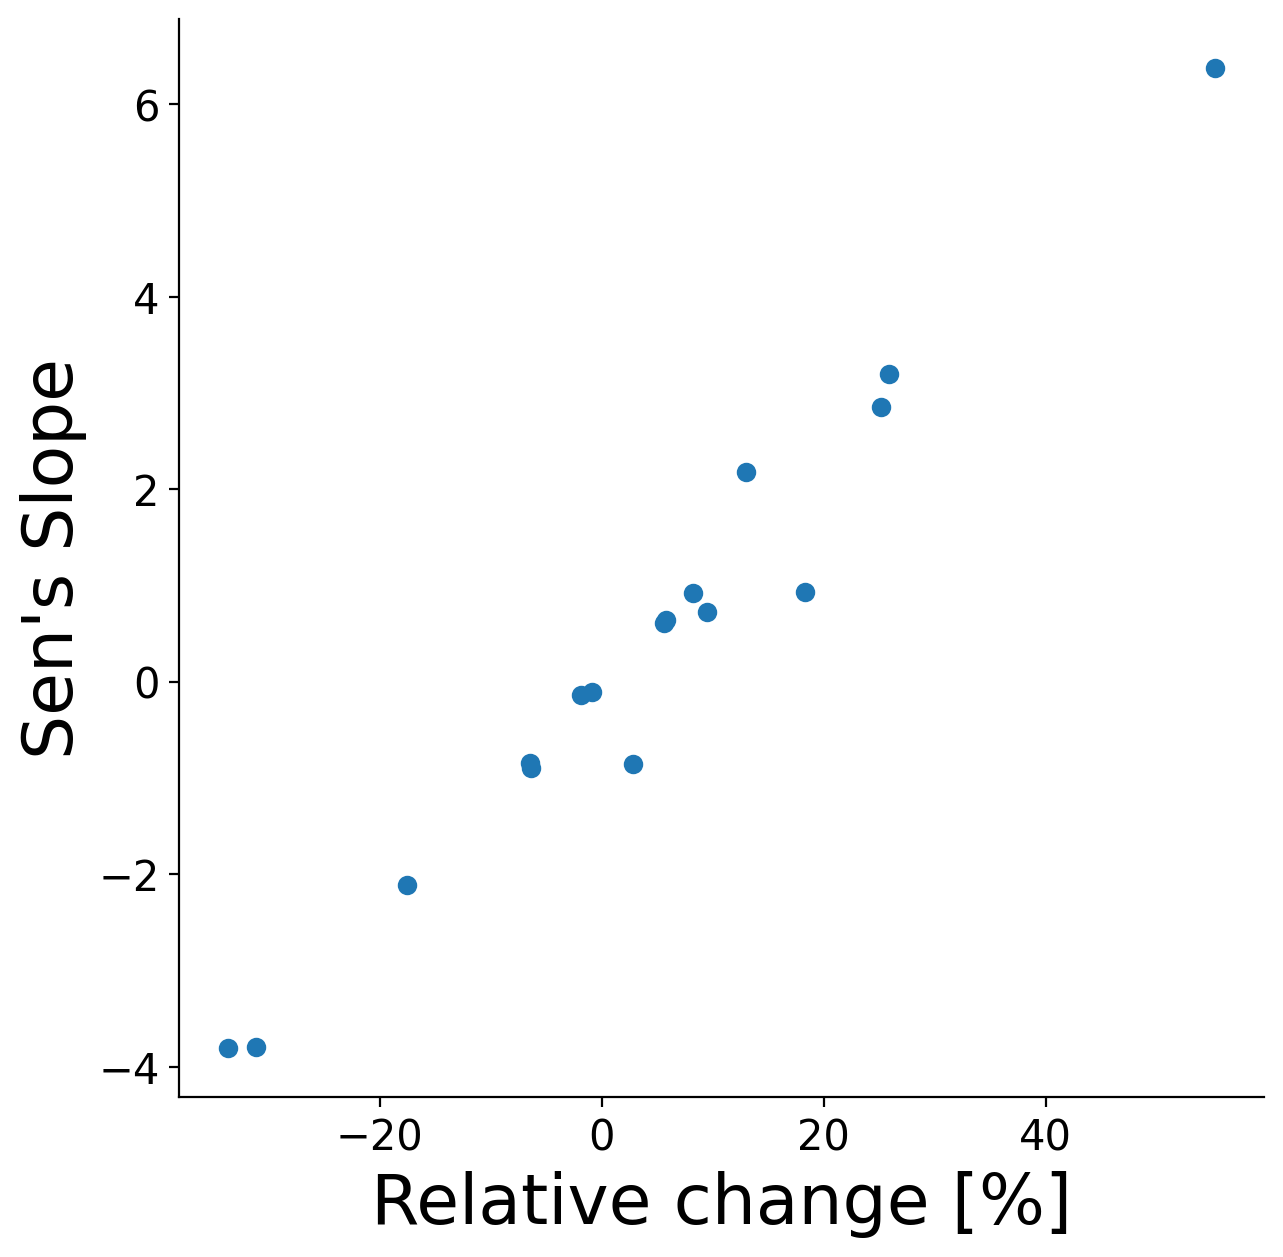

In [46]:
f, ax = plt.subplots(figsize=(7, 7))
ax = set_font(ax, 15)
plt.scatter(df_res_all['Rel_change'], df_res_all['Slope'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('Relative change [%]', size=25)
plt.ylabel("Sen's Slope", size=25)

In [47]:
fout = '../Figures/FHN_SenRelChange.pdf'
f.savefig(fout, dpi=300, bbox_inches='tight')

In [48]:
DF2020 = DF_all[DF_all['year']==2020].reset_index(drop=True)
DF2020

,year,region,median_FHN,median_rel_FHN,Continent
0,2020,Central Asia,0.103785,12.948105,Asia
1,2020,Eastern Africa,0.244353,-6.387893,Africa
2,2020,Eastern Asia,0.289621,5.556444,Asia
3,2020,Eastern Europe,0.465057,5.813708,Europe
4,2020,Middle Africa,0.363584,-33.660561,Africa
5,2020,Northern Africa,0.121277,2.821623,Africa
6,2020,Northern America,0.426644,-1.844602,America
7,2020,Northern Europe,0.488543,8.210410,Europe
8,2020,Oceania,0.239313,25.875269,Oceania
9,2020,South America,0.410517,-17.549936,America


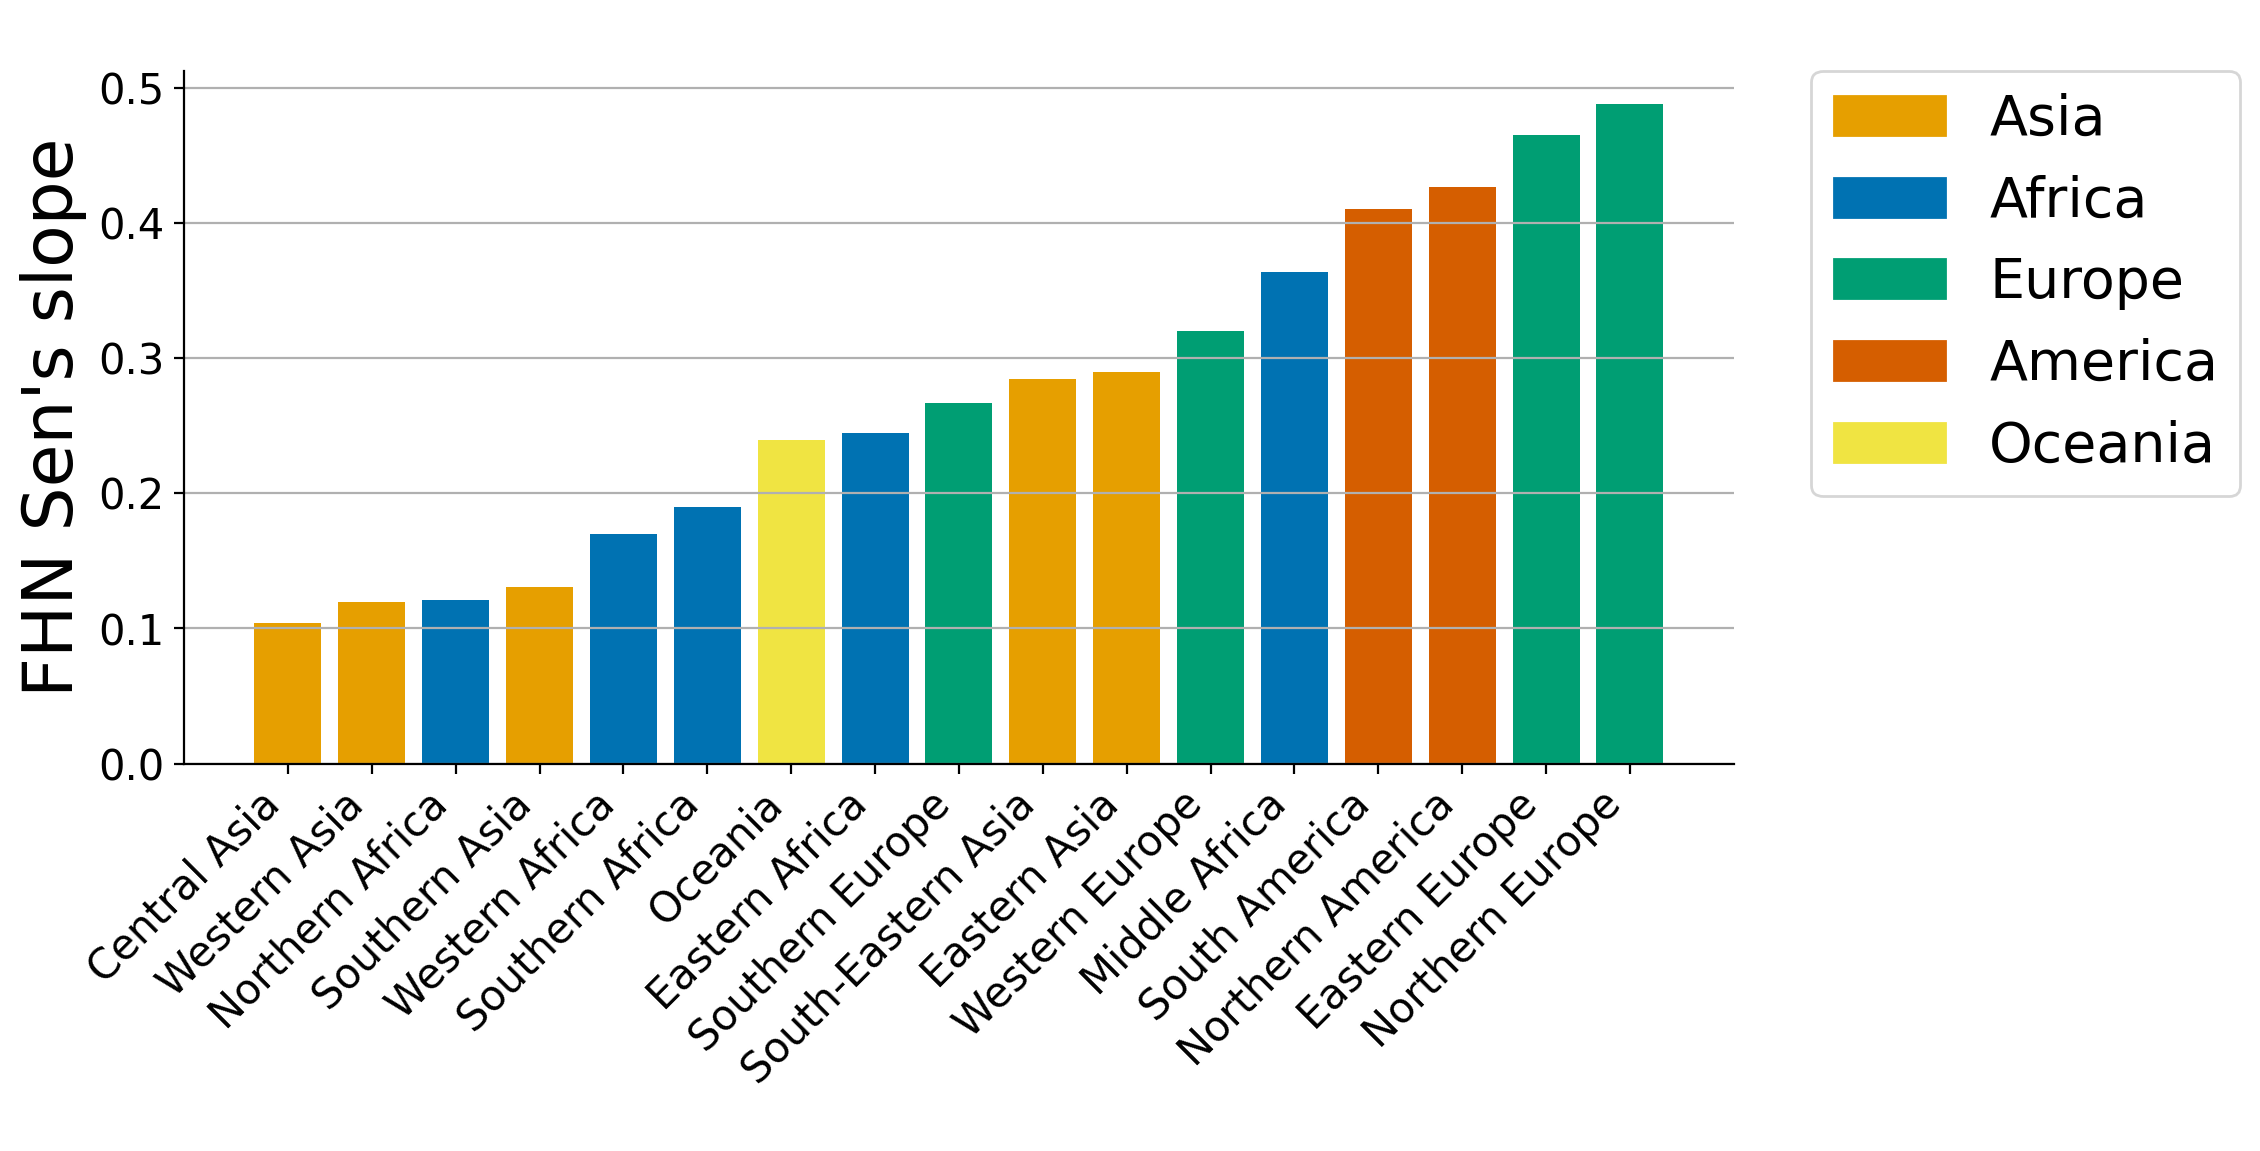

In [50]:
DF2020 = DF2020.sort_values('median_FHN')
colors = DF2020['region'].map(REGION_TO_CONTINENT).map(CONTINENT_COLORS)
# Plotting the bar plot
f, ax = plt.subplots(figsize=(10, 4.5))
ax = set_font(ax, 15)
plt.bar(DF2020['region'], DF2020['median_FHN'], color=colors)
# Adding labels and title
plt.xlabel(' ')
plt.ylabel('FHN '+"Sen's slope", size=25)
plt.title(' ', size=16)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Creating legend patches
patches = [mpatches.Patch(color=color, label=continent) for continent, color in CONTINENT_COLORS.items()]
# Adding the legend outside the plot
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=20)
plt.xticks(rotation=45, ha='right');